In [81]:
import seaborn as sns

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
from sklearn.impute import KNNImputer

In [84]:
import numpy as np

In [85]:
from sklearn.preprocessing import PowerTransformer

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
from sklearn.decomposition import PCA

In [88]:
import matplotlib.pyplot as plt

#  Step 1:  Importing DataSet

In [89]:
import pandas as pd

In [90]:
df=pd.read_csv("House Prices - Advanced Regression Techniques.csv")

# Step 2: Undersatnding DataSet

In [91]:
df.shape

(1460, 81)

In [92]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

# Step 3: EDA

### Finding Missing Values

In [94]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Finding Duplicate Rows

In [95]:
df.duplicated().sum()

np.int64(0)

### Checking target column 

In [96]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: >

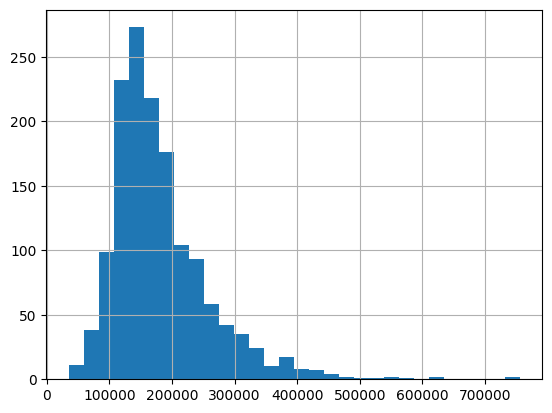

In [97]:
df['SalePrice'].hist(bins=30)

In [98]:
df['SalePrice'].skew()

np.float64(1.8828757597682129)

<Axes: xlabel='SalePrice'>

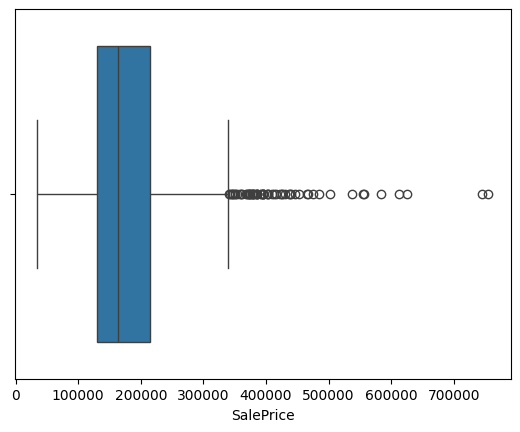

In [99]:
sns.boxplot(x=df['SalePrice'])

### Corelation between numerical columns with target column

In [100]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Corelation betweeen categorical columns with traget column

In [101]:
df.groupby('GarageType')['SalePrice'].mean().sort_values(ascending=False)

GarageType
BuiltIn    254751.738636
Attchd     202892.656322
Basment    160570.684211
2Types     151283.333333
Detchd     134091.162791
CarPort    109962.111111
Name: SalePrice, dtype: float64

# Step 4: Train Test Split

In [102]:
X=df.drop('SalePrice', axis=1)
Y=df['SalePrice']

In [103]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [104]:
X_train.shape

(1168, 80)

In [105]:
X_test.shape

(292, 80)

In [106]:
Y_train.shape

(1168,)

In [107]:
Y_test.shape

(292,)

# Step 5: Missing Value Handling

In [108]:
X_train.isnull().sum()[X_train.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
LotFrontage      217
GarageType        64
GarageYrBlt       64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtCond          28
BsmtFinType1      28
BsmtExposure      28
BsmtQual          28
BsmtFinType2      28
MasVnrArea         6
Electrical         1
dtype: int64

In [109]:
X_train[
    X_train.isnull().sum()[X_train.isnull().sum() > 0].index
].dtypes

LotFrontage     float64
Alley               str
MasVnrType          str
MasVnrArea      float64
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Electrical          str
FireplaceQu         str
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
PoolQC              str
Fence               str
MiscFeature         str
dtype: object

### Analyzing only numerical columns

In [110]:
num_cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

for col in num_cols:
    print(col)
    print("Skewness:", X_train[col].skew())
    print("-"*40)

LotFrontage
Skewness: 2.406787027289136
----------------------------------------
MasVnrArea
Skewness: 2.286423439127738
----------------------------------------
GarageYrBlt
Skewness: -0.6664884944671419
----------------------------------------


In [111]:
median_mas = X_train['MasVnrArea'].median()
median_garage = X_train['GarageYrBlt'].median()

X_train['MasVnrArea'] = X_train['MasVnrArea'].fillna(median_mas)
X_test['MasVnrArea'] = X_test['MasVnrArea'].fillna(median_mas)

X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(median_garage)
X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(median_garage)

In [112]:
knn = KNNImputer(n_neighbors=5)
X_train[['LotFrontage']] = knn.fit_transform(
    X_train[['LotFrontage']]
)
X_test[['LotFrontage']] = knn.transform(
    X_test[['LotFrontage']]
)

In [113]:
X_train[['LotFrontage', 'MasVnrArea', 'GarageYrBlt']].isnull().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

### Analyzing only categorical columns

In [114]:
no_feature_cols = [
    'Alley',
    'PoolQC',
    'Fence',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'MiscFeature',
    'MasVnrType'
]

X_train[no_feature_cols] = X_train[no_feature_cols].fillna('Missing')
X_test[no_feature_cols] = X_test[no_feature_cols].fillna('Missing')

In [115]:
X_train[no_feature_cols].isnull().sum()

Alley           0
PoolQC          0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
MiscFeature     0
MasVnrType      0
dtype: int64

In [116]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

Electrical    1
dtype: int64

In [117]:
mode_value = X_train['Electrical'].mode()[0]

X_train['Electrical'] = X_train['Electrical'].fillna(mode_value)

X_test['Electrical'] = X_test['Electrical'].fillna(mode_value)

In [118]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

Series([], dtype: int64)

# Step 6: Outlier Handling

In [119]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[num_cols].skew().sort_values(ascending=False)

MiscVal          22.053579
PoolArea         14.396098
LotArea          11.958088
3SsnPorch         9.833911
LowQualFinSF      9.199456
KitchenAbvGr      4.445055
BsmtFinSF2        4.217895
ScreenPorch       4.090393
BsmtHalfBath      4.005786
EnclosedPorch     3.163946
LotFrontage       2.666498
OpenPorchSF       2.331890
MasVnrArea        2.294117
BsmtFinSF1        1.862132
TotalBsmtSF       1.723881
WoodDeckSF        1.587330
MSSubClass        1.438804
GrLivArea         1.425139
1stFlrSF          1.422162
BsmtUnfSF         0.910628
2ndFlrSF          0.801209
OverallCond       0.733180
TotRmsAbvGrd      0.687336
HalfBath          0.651296
Fireplaces        0.637526
BsmtFullBath      0.612032
BedroomAbvGr      0.289882
MoSold            0.241761
OverallQual       0.196575
GarageArea        0.109110
YrSold            0.082593
FullBath          0.038169
Id                0.000920
GarageCars       -0.389732
YearRemodAdd     -0.508067
YearBuilt        -0.623404
GarageYrBlt      -0.694472
d

In [120]:
zscore_cols = [
    'BedroomAbvGr',
    'MoSold',
    'OverallQual',
    'GarageArea',
    'YrSold',
    'FullBath',
    'GarageCars'
]

for col in zscore_cols:

    mean = X_train[col].mean()
    std = X_train[col].std()

    upper_limit = mean + 3 * std
    lower_limit = mean - 3 * std

    X_train[col] = np.where(
        X_train[col] > upper_limit,
        upper_limit,
        np.where(
            X_train[col] < lower_limit,
            lower_limit,
            X_train[col]
        )
    )

    X_test[col] = np.where(
        X_test[col] > upper_limit,
        upper_limit,
        np.where(
            X_test[col] < lower_limit,
            lower_limit,
            X_test[col]
        )
    )

In [121]:
iqr_cols = [
    'YearRemodAdd',
    'MiscVal',
    'PoolArea',
    'LotArea',
    '3SsnPorch',
    'LowQualFinSF',
    'KitchenAbvGr',
    'BsmtFinSF2',
    'ScreenPorch',
    'BsmtHalfBath',
    'EnclosedPorch',
    'LotFrontage',
    'OpenPorchSF',
    'MasVnrArea',
    'BsmtFinSF1',
    'TotalBsmtSF',
    'WoodDeckSF',
    'MSSubClass',
    'GrLivArea',
    '1stFlrSF',
    'BsmtUnfSF',
    '2ndFlrSF',
    'OverallCond',
    'TotRmsAbvGrd',
    'HalfBath',
    'Fireplaces',
    'BsmtFullBath',
    'YearBuilt',
    'GarageYrBlt'
]

for col in iqr_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    X_train[col] = np.where(
        X_train[col] > upper_limit,
        upper_limit,
        np.where(
            X_train[col] < lower_limit,
            lower_limit,
            X_train[col]
        )
    )

    X_test[col] = np.where(
        X_test[col] > upper_limit,
        upper_limit,
        np.where(
            X_test[col] < lower_limit,
            lower_limit,
            X_test[col]
        )
    )

In [122]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[num_cols].skew().sort_values(ascending=False)

MasVnrArea       1.274889
OpenPorchSF      1.153998
WoodDeckSF       1.090342
MSSubClass       1.030201
BsmtUnfSF        0.793334
2ndFlrSF         0.787900
BsmtFinSF1       0.727257
HalfBath         0.651296
1stFlrSF         0.613564
OverallCond      0.591797
GrLivArea        0.586859
Fireplaces       0.572812
BsmtFullBath     0.571111
TotRmsAbvGrd     0.360120
MoSold           0.241761
OverallQual      0.239986
TotalBsmtSF      0.235060
LotArea          0.219944
YrSold           0.082593
LotFrontage      0.052796
FullBath         0.038169
BedroomAbvGr     0.018455
GarageArea       0.002179
Id               0.000920
ScreenPorch      0.000000
BsmtFinSF2       0.000000
3SsnPorch        0.000000
BsmtHalfBath     0.000000
LowQualFinSF     0.000000
MiscVal          0.000000
PoolArea         0.000000
KitchenAbvGr     0.000000
EnclosedPorch    0.000000
GarageCars      -0.389732
YearRemodAdd    -0.508067
YearBuilt       -0.613735
GarageYrBlt     -0.691831
dtype: float64

# Step 7: Transformation

In [123]:
transform_cols = [
    'MasVnrArea',
    'OpenPorchSF',
    'WoodDeckSF',
    'MSSubClass'
]

pt = PowerTransformer(method='yeo-johnson')

X_train[transform_cols] = pt.fit_transform(
    X_train[transform_cols]
)

X_test[transform_cols] = pt.transform(
    X_test[transform_cols]
)

In [124]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[num_cols].skew().sort_values(ascending=False)

BsmtUnfSF        0.793334
2ndFlrSF         0.787900
BsmtFinSF1       0.727257
HalfBath         0.651296
1stFlrSF         0.613564
OverallCond      0.591797
GrLivArea        0.586859
Fireplaces       0.572812
BsmtFullBath     0.571111
MasVnrArea       0.374998
TotRmsAbvGrd     0.360120
MoSold           0.241761
OverallQual      0.239986
TotalBsmtSF      0.235060
LotArea          0.219944
WoodDeckSF       0.155177
YrSold           0.082593
LotFrontage      0.052796
MSSubClass       0.046237
FullBath         0.038169
BedroomAbvGr     0.018455
GarageArea       0.002179
Id               0.000920
MiscVal          0.000000
LowQualFinSF     0.000000
BsmtFinSF2       0.000000
ScreenPorch      0.000000
BsmtHalfBath     0.000000
KitchenAbvGr     0.000000
PoolArea         0.000000
3SsnPorch        0.000000
EnclosedPorch    0.000000
OpenPorchSF     -0.061045
GarageCars      -0.389732
YearRemodAdd    -0.508067
YearBuilt       -0.613735
GarageYrBlt     -0.691831
dtype: float64

# Step 8: Feature Engineering

In [125]:
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']

X_train['RemodelAge'] = X_train['YrSold'] - X_train['YearRemodAdd']

X_train['GarageAge'] = X_train['YrSold'] - X_train['GarageYrBlt']


X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']

X_test['RemodelAge'] = X_test['YrSold'] - X_test['YearRemodAdd']

X_test['GarageAge'] = X_test['YrSold'] - X_test['GarageYrBlt']


X_train[['HouseAge', 'RemodelAge', 'GarageAge']].head()

,HouseAge,RemodelAge,GarageAge
254,53.0,53.0,53.0
1066,16.0,15.0,16.0
638,98.0,58.0,28.0
799,70.0,57.0,68.0
380,86.0,60.0,86.0


In [126]:
cols_to_drop = [
    'YearBuilt',
    'YearRemodAdd',
    'GarageYrBlt'
]

X_train = X_train.drop(columns=cols_to_drop)

X_test = X_test.drop(columns=cols_to_drop)

In [127]:
X_train.shape

(1168, 80)

In [128]:
X_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
       'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPor

# Step 9: Encoding

In [129]:
cat_cols = X_train.select_dtypes(include='object').columns

cat_cols

C:\Users\Digital\AppData\Local\Temp\ipykernel_10520\2872357755.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [130]:
ordinal_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'GarageQual',
    'GarageCond',
    'FireplaceQu',
    'PoolQC',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'Functional'
]

len(ordinal_cols)

14

In [131]:
nominal_cols = [
    'MSZoning',
    'Street',
    'Alley',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'GarageType',
    'GarageFinish',
    'PavedDrive',
    'Fence',
    'MiscFeature',
    'SaleType',
    'SaleCondition'
]

len(nominal_cols)

29

In [132]:
len(ordinal_cols) + len(nominal_cols)

43

In [133]:
set(cat_cols) - set(ordinal_cols) - set(nominal_cols)

set()

In [134]:
X_train = pd.get_dummies(
    X_train,
    columns=nominal_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=nominal_cols,
    drop_first=True
)


X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [135]:
X_train.shape

(1168, 210)

In [136]:
X_test.shape

(292, 210)

In [137]:
X_train.columns.equals(X_test.columns)

True

In [138]:
X_train[ordinal_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,GarageQual,GarageCond,FireplaceQu,PoolQC,BsmtExposure,BsmtFinType1,BsmtFinType2,Functional
254,TA,Gd,TA,TA,TA,TA,TA,TA,Missing,Missing,No,Rec,Unf,Typ
1066,Gd,TA,Gd,TA,Gd,TA,TA,TA,TA,Missing,No,Unf,Unf,Typ
638,TA,TA,Fa,TA,Gd,TA,Missing,Missing,Missing,Missing,No,Unf,Unf,Typ
799,TA,TA,Gd,TA,Ex,Gd,TA,TA,TA,Missing,No,ALQ,Unf,Typ
380,TA,TA,TA,TA,TA,Gd,TA,TA,Gd,Missing,No,LwQ,Unf,Typ


In [139]:
for col in ordinal_cols:
    print(col)
    print(sorted(X_train[col].dropna().unique()))
    print("-" * 50)

ExterQual
['Ex', 'Fa', 'Gd', 'TA']
--------------------------------------------------
ExterCond
['Ex', 'Fa', 'Gd', 'Po', 'TA']
--------------------------------------------------
BsmtQual
['Ex', 'Fa', 'Gd', 'Missing', 'TA']
--------------------------------------------------
BsmtCond
['Fa', 'Gd', 'Missing', 'Po', 'TA']
--------------------------------------------------
HeatingQC
['Ex', 'Fa', 'Gd', 'Po', 'TA']
--------------------------------------------------
KitchenQual
['Ex', 'Fa', 'Gd', 'TA']
--------------------------------------------------
GarageQual
['Ex', 'Fa', 'Gd', 'Missing', 'Po', 'TA']
--------------------------------------------------
GarageCond
['Ex', 'Fa', 'Gd', 'Missing', 'Po', 'TA']
--------------------------------------------------
FireplaceQu
['Ex', 'Fa', 'Gd', 'Missing', 'Po', 'TA']
--------------------------------------------------
PoolQC
['Ex', 'Fa', 'Gd', 'Missing']
--------------------------------------------------
BsmtExposure
['Av', 'Gd', 'Missing', 'Mn', 'No']


### Group 1: Quality-Type Columns

Po < Fa < TA < Gd < Ex

In [140]:
quality_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'GarageQual',
    'GarageCond',
    'FireplaceQu',
    'PoolQC'
]

quality_map = {
    'Missing': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

for col in quality_cols:
    X_train[col] = X_train[col].map(quality_map)
    X_test[col] = X_test[col].map(quality_map)

### Group 2: BsmtExposure

Missing < No < Mn < Av < Gd

In [141]:
exposure_map = {
    'Missing': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

X_train['BsmtExposure'] = X_train['BsmtExposure'].map(exposure_map)
X_test['BsmtExposure'] = X_test['BsmtExposure'].map(exposure_map)

### Group 3: BsmtFinType1 & BsmtFinType2

Missing < Unf < LwQ < Rec < BLQ < ALQ < GLQ

In [142]:
fin_map = {
    'Missing': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

for col in ['BsmtFinType1', 'BsmtFinType2']:
    X_train[col] = X_train[col].map(fin_map)
    X_test[col] = X_test[col].map(fin_map)

### Group 4: Functional

Sev < Maj2 < Maj1 < Mod < Min2 < Min1 < Typ

In [143]:
functional_map = {
    'Sev': 1,
    'Maj2': 2,
    'Maj1': 3,
    'Mod': 4,
    'Min2': 5,
    'Min1': 6,
    'Typ': 7
}

X_train['Functional'] = X_train['Functional'].map(functional_map)
X_test['Functional'] = X_test['Functional'].map(functional_map)

In [144]:
X_train[ordinal_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,GarageQual,GarageCond,FireplaceQu,PoolQC,BsmtExposure,BsmtFinType1,BsmtFinType2,Functional
254,3,4,3,3,3,3,3,3,0,0,1,3,1,7
1066,4,3,4,3,4,3,3,3,3,0,1,1,1,7
638,3,3,2,3,4,3,0,0,0,0,1,1,1,7
799,3,3,4,3,5,4,3,3,3,0,1,5,1,7
380,3,3,3,3,3,4,3,3,4,0,1,2,1,7


In [145]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1168 entries, 254 to 1126
Columns: 210 entries, Id to SaleCondition_Partial
dtypes: bool(159), float64(36), int64(15)
memory usage: 655.9 KB


In [146]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255,-1.160995,70.0,8400.0,5.0,6.0,-0.839920,3,4,3,...,False,False,False,False,True,False,False,False,True,False
1066,1067,0.499847,59.0,7837.0,6.0,7.0,-0.839920,4,3,4,...,False,False,False,False,True,False,False,False,True,False
638,639,-0.523570,67.0,8777.0,5.0,7.0,-0.839920,3,3,2,...,False,False,False,False,True,False,False,False,True,False
799,800,0.239108,60.0,7200.0,5.0,7.0,1.262816,3,3,4,...,False,False,False,False,True,False,False,False,True,False
380,381,0.239108,50.0,5000.0,5.0,6.0,-0.839920,3,3,3,...,False,False,False,False,True,False,False,False,True,False


# Step 10: Feature Scaling

In [147]:
# remove id column 

X_train = X_train.drop('Id', axis=1)
X_test = X_test.drop('Id', axis=1)

In [148]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [149]:
X_train_scaled.shape

(1168, 209)

In [150]:
X_test_scaled.shape

(292, 209)

In [151]:
X_train_scaled

array([[-1.1609953 ,  0.02997779, -0.37000422, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.49984664, -0.6067627 , -0.52655662, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.52356981, -0.14367871, -0.2651725 , ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [-1.1609953 , -0.5488772 , -0.43340377, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.23910788, -0.8383047 , -0.58077992, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 1.43537748, -0.9540757 , -1.6813739 , ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(1168, 209))

# Step 11: PCA

In [152]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

In [153]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

cumulative_variance

array([0.07765193, 0.11347801, 0.14218085, 0.16641287, 0.18797742,
       0.20726192, 0.22472068, 0.24145528, 0.25684511, 0.27024931,
       0.28362306, 0.29656554, 0.30932169, 0.32169961, 0.33357516,
       0.34487148, 0.35610275, 0.36689556, 0.37759322, 0.38794706,
       0.39816696, 0.40810039, 0.41792405, 0.42769714, 0.43711374,
       0.44623806, 0.45518248, 0.46402614, 0.47271416, 0.48133882,
       0.48979654, 0.49817401, 0.50627079, 0.51423142, 0.52210539,
       0.52993597, 0.53769845, 0.54525759, 0.55264903, 0.55996206,
       0.56718372, 0.57421059, 0.58111809, 0.58797466, 0.59474468,
       0.60146925, 0.60810816, 0.6146655 , 0.62115923, 0.6275023 ,
       0.63374342, 0.63993633, 0.64606521, 0.6521395 , 0.65812696,
       0.66404262, 0.66986282, 0.67563307, 0.68131147, 0.68694494,
       0.69252973, 0.69804927, 0.70351628, 0.70890734, 0.7142136 ,
       0.71948917, 0.72473796, 0.72991581, 0.73506866, 0.740138  ,
       0.74513944, 0.75010185, 0.75501953, 0.7598354 , 0.76462

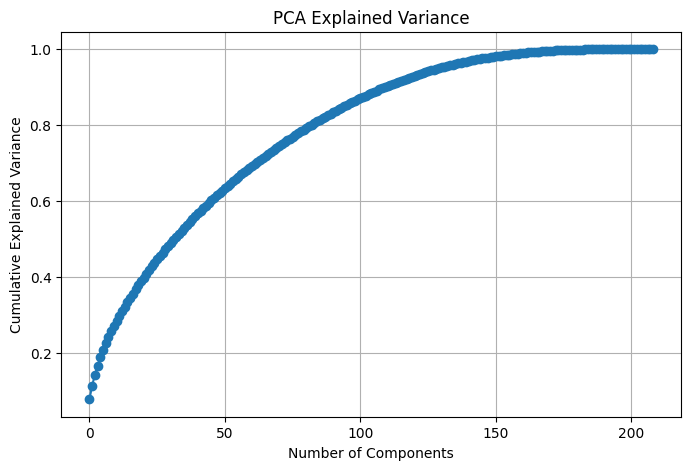

In [154]:
plt.figure(figsize=(8,5))

plt.plot(
    cumulative_variance,
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance')

plt.grid(True)

plt.show()

In [155]:

n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(n_components)

130


In [156]:
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

In [157]:
X_train_pca.shape

(1168, 130)

In [158]:
X_test_pca.shape

(292, 130)

# Step 12: Model

In [160]:
from sklearn.linear_model import LinearRegression

# Create Model
lr = LinearRegression()

# Train Model
lr.fit(X_train_pca, Y_train)

# Predictions
y_train_pred = lr.predict(X_train_pca)
y_test_pred = lr.predict(X_test_pca)

# Step 13: Metrics

In [162]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# Training Metrics
# =========================

train_r2 = r2_score(Y_train, y_train_pred)

train_adj_r2 = 1 - (
    (1 - train_r2) * (len(Y_train) - 1)
) / (
    len(Y_train) - X_train_pca.shape[1] - 1
)

# =========================
# Testing Metrics
# =========================

test_r2 = r2_score(Y_test, y_test_pred)

test_adj_r2 = 1 - (
    (1 - test_r2) * (len(Y_test) - 1)
) / (
    len(Y_test) - X_test_pca.shape[1] - 1
)

mae = mean_absolute_error(Y_test, y_test_pred)

mse = mean_squared_error(Y_test, y_test_pred)

rmse = np.sqrt(mse)

# =========================
# Print Results
# =========================

print("========== Training Metrics ==========")
print("R² Score           :", train_r2)
print("Adjusted R² Score  :", train_adj_r2)

print("\n========== Testing Metrics ==========")
print("R² Score           :", test_r2)
print("Adjusted R² Score  :", test_adj_r2)

print("\n========== Error Metrics ==========")
print("MAE                :", mae)
print("MSE                :", mse)
print("RMSE               :", rmse)


========== Training Metrics ==========
R² Score           : 0.8838220134463058
Adjusted R² Score  : 0.8692577528368746

========== Testing Metrics ==========
R² Score           : 0.8517841757086535
Adjusted R² Score  : 0.7321068020572556

========== Error Metrics ==========
MAE                : 21582.424109334017
MSE                : 1136863721.3817573
RMSE               : 33717.40976679195


# Model Evaluation

## Ridge Regression

In [163]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_pca, Y_train)

ridge_train_pred = ridge.predict(X_train_pca)
ridge_test_pred = ridge.predict(X_test_pca)

ridge_train_r2 = r2_score(Y_train, ridge_train_pred)
ridge_test_r2 = r2_score(Y_test, ridge_test_pred)

print("Ridge Train R² :", ridge_train_r2)
print("Ridge Test R²  :", ridge_test_r2)

Ridge Train R² : 0.8838219322845361
Ridge Test R²  : 0.8517926024711586


## Lasso Regression

In [164]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

lasso = Lasso(alpha=1.0)

lasso.fit(X_train_pca, Y_train)

lasso_train_pred = lasso.predict(X_train_pca)
lasso_test_pred = lasso.predict(X_test_pca)

lasso_train_r2 = r2_score(Y_train, lasso_train_pred)
lasso_test_r2 = r2_score(Y_test, lasso_test_pred)

print("Lasso Train R² :", lasso_train_r2)
print("Lasso Test R²  :", lasso_test_r2)

Lasso Train R² : 0.8838219907421144
Lasso Test R²  : 0.8517956292951243


## Elastic Net Regression

In [165]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

elastic = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    random_state=42
)

elastic.fit(X_train_pca, Y_train)

elastic_train_pred = elastic.predict(X_train_pca)
elastic_test_pred = elastic.predict(X_test_pca)

elastic_train_r2 = r2_score(Y_train, elastic_train_pred)
elastic_test_r2 = r2_score(Y_test, elastic_test_pred)

print("Elastic Net Train R² :", elastic_train_r2)
print("Elastic Net Test R²  :", elastic_test_r2)

Elastic Net Train R² : 0.8726182612666535
Elastic Net Test R²  : 0.8431194796964104


### Final Comparison Table

In [167]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net Regression"
    ],
    "Train R²": [
        train_r2,
        ridge_train_r2,
        lasso_train_r2,
        elastic_train_r2
    ],
    "Test R²": [
        test_r2,
        ridge_test_r2,
        lasso_test_r2,
        elastic_test_r2
    ]
})

comparison

,Model,Train R²,Test R²
0,Linear Regression,0.883822,0.851784
1,Ridge Regression,0.883822,0.851793
2,Lasso Regression,0.883822,0.851796
3,Elastic Net Regression,0.872618,0.843119
